# GSM8K forgetting-gap analysis

This notebook measures two related quantities from the greedy train-set evaluations:

1. **Lagged forgetting rate at Δ steps**: among query/checkpoint pairs solved at step `s`, the fraction incorrect at `s + Δ`, pooled over every valid starting checkpoint.
2. **Current forgetting gap at step `s`**: `ever-solved accuracy − current accuracy`, where ever-solved means greedily correct at any checkpoint up through `s`.

The lagged metric answers “how often does a solved query fail after 25, 50, … steps?” The current gap measures how much previously demonstrated capability is absent at each checkpoint.

Loaded 7,473 queries at 13 checkpoints: [0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]

Forgetting by checkpoint


,step,current_accuracy,ever_solved_accuracy,forgetting_gap,forgetting_ratio_among_ever_solved
0,0,70.49%,70.49%,0.00%,0.00%
1,25,75.06%,82.54%,7.48%,9.06%
2,50,71.85%,86.40%,14.56%,16.85%
3,75,72.98%,88.77%,15.79%,17.79%
4,100,74.53%,90.20%,15.67%,17.37%
5,125,72.69%,91.14%,18.45%,20.25%
6,150,73.01%,91.68%,18.67%,20.36%
7,175,71.68%,92.12%,20.43%,22.18%
8,200,73.52%,92.49%,18.97%,20.52%
9,225,74.52%,92.73%,18.21%,19.64%



Forgetting by lag (pooled over valid checkpoint pairs)


,lag,forgetting_rate,forgotten,solved_at_start,checkpoint_pairs,mean_pairwise_rate
0,25,10.32%,6789,65801,12,10.32%
1,50,11.20%,6740,60187,11,11.21%
2,75,11.40%,6221,54578,10,11.40%
3,100,11.57%,5670,49009,9,11.56%
4,125,12.01%,5228,43515,8,12.01%
5,150,12.25%,4673,38158,7,12.24%
6,175,12.34%,4037,32702,6,12.35%
7,200,12.20%,3327,27270,5,12.20%
8,225,12.16%,2639,21700,4,12.15%
9,250,12.18%,1979,16246,3,12.17%


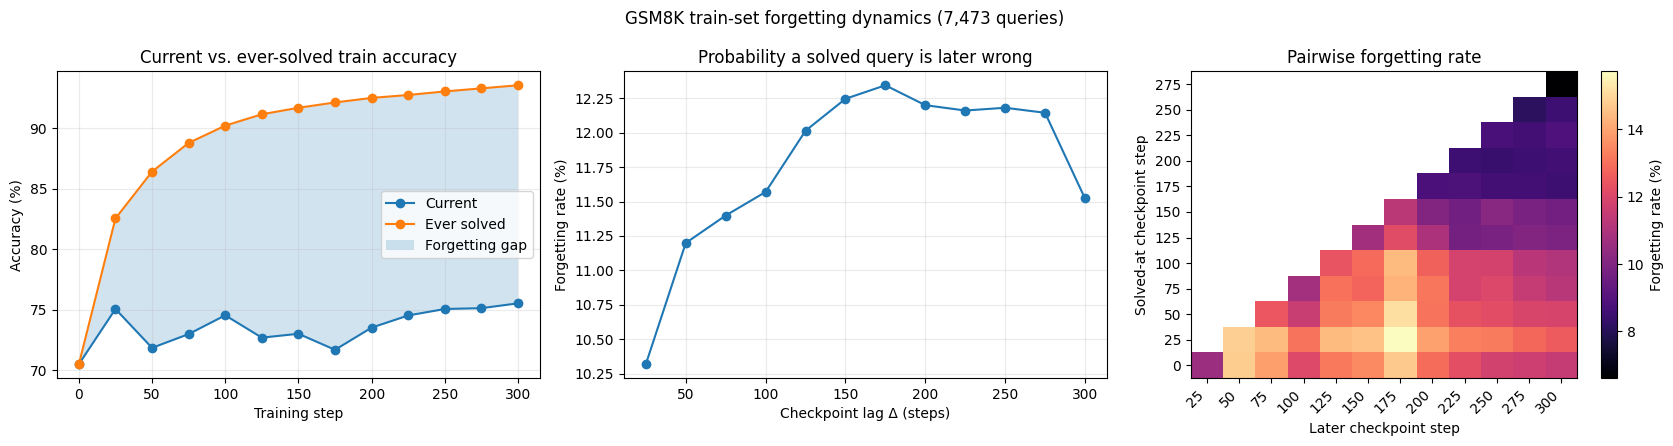

Final step 300: current=75.53%, ever-solved=93.54%, gap=18.01% (19.26% of ever-solved queries).
Saved CSV summaries and figure under /Users/fangyuanyu/Implementation/arl/output/forget_gap


In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Work whether the notebook is launched from the repository root or this directory.
run_dir = Path.cwd()
if not list(run_dir.glob("step*_train.jsonl")):
    run_dir = Path("output/forget_gap")

step_files = sorted(
    run_dir.glob("step*_train.jsonl"),
    key=lambda p: int(re.search(r"step(\d+)_train", p.name).group(1)),
)
assert step_files, f"No step*_train.jsonl files found under {run_dir.resolve()}"

records = []
for path in step_files:
    with path.open() as f:
        records.extend(json.loads(line) for line in f if line.strip())

evals = pd.DataFrame(records)
required = {"idx", "step", "correct", "gold"}
assert required <= set(evals), f"Missing columns: {required - set(evals)}"
assert not evals.duplicated(["idx", "step"]).any(), "Duplicate (idx, step) records"

correct = (
    evals.pivot(index="idx", columns="step", values="correct")
    .sort_index(axis=0)
    .sort_index(axis=1)
)
assert not correct.isna().any().any(), "Checkpoints do not cover the same query set"
correct = correct.astype(bool)
steps = correct.columns.to_numpy(dtype=int)
assert np.all(np.diff(steps) > 0)

# Checkpoint-level current accuracy and the ever-solved envelope.
ever_solved = correct.cummax(axis=1)
checkpoint_summary = pd.DataFrame({
    "step": steps,
    "current_accuracy": correct.mean(axis=0).to_numpy(),
    "ever_solved_accuracy": ever_solved.mean(axis=0).to_numpy(),
})
checkpoint_summary["forgetting_gap"] = (
    checkpoint_summary["ever_solved_accuracy"]
    - checkpoint_summary["current_accuracy"]
)
checkpoint_summary["forgetting_ratio_among_ever_solved"] = [
    ((ever_solved[s] & ~correct[s]).sum() / ever_solved[s].sum())
    if ever_solved[s].sum() else np.nan
    for s in steps
]

# Pairwise forgetting: solved at start_step, incorrect exactly lag steps later.
pair_rows = []
step_set = set(steps)
for start_step in steps:
    solved = correct[start_step]
    for end_step in steps:
        if end_step <= start_step:
            continue
        at_risk = int(solved.sum())
        forgotten = int((solved & ~correct[end_step]).sum())
        pair_rows.append({
            "start_step": start_step,
            "end_step": end_step,
            "lag": end_step - start_step,
            "solved_at_start": at_risk,
            "forgotten": forgotten,
            "forgetting_rate": forgotten / at_risk if at_risk else np.nan,
        })

pairwise = pd.DataFrame(pair_rows)
lag_summary = (
    pairwise.groupby("lag", as_index=False)
    .agg(
        forgotten=("forgotten", "sum"),
        solved_at_start=("solved_at_start", "sum"),
        checkpoint_pairs=("start_step", "size"),
        mean_pairwise_rate=("forgetting_rate", "mean"),
    )
)
lag_summary["forgetting_rate"] = (
    lag_summary["forgotten"] / lag_summary["solved_at_start"]
)
lag_summary = lag_summary[
    ["lag", "forgetting_rate", "forgotten", "solved_at_start", "checkpoint_pairs", "mean_pairwise_rate"]
]

# Persist tidy results for downstream comparisons.
checkpoint_summary.to_csv(run_dir / "forgetting_by_checkpoint.csv", index=False)
lag_summary.to_csv(run_dir / "forgetting_by_lag.csv", index=False)
pairwise.to_csv(run_dir / "forgetting_pairwise.csv", index=False)

print(f"Loaded {len(correct):,} queries at {len(steps)} checkpoints: {steps.tolist()}")
print("\nForgetting by checkpoint")
display(checkpoint_summary.style.format({
    "current_accuracy": "{:.2%}",
    "ever_solved_accuracy": "{:.2%}",
    "forgetting_gap": "{:.2%}",
    "forgetting_ratio_among_ever_solved": "{:.2%}",
}))
print("\nForgetting by lag (pooled over valid checkpoint pairs)")
display(lag_summary.style.format({
    "forgetting_rate": "{:.2%}",
    "mean_pairwise_rate": "{:.2%}",
}))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(steps, checkpoint_summary["current_accuracy"] * 100, "o-", label="Current")
axes[0].plot(steps, checkpoint_summary["ever_solved_accuracy"] * 100, "o-", label="Ever solved")
axes[0].fill_between(
    steps,
    checkpoint_summary["current_accuracy"] * 100,
    checkpoint_summary["ever_solved_accuracy"] * 100,
    alpha=0.2,
    label="Forgetting gap",
)
axes[0].set(title="Current vs. ever-solved train accuracy", xlabel="Training step", ylabel="Accuracy (%)")
axes[0].legend()

axes[1].plot(lag_summary["lag"], lag_summary["forgetting_rate"] * 100, "o-")
axes[1].set(title="Probability a solved query is later wrong", xlabel="Checkpoint lag Δ (steps)", ylabel="Forgetting rate (%)")

matrix = pairwise.pivot(index="start_step", columns="end_step", values="forgetting_rate") * 100
image = axes[2].imshow(matrix, origin="lower", aspect="auto", cmap="magma")
axes[2].set(
    title="Pairwise forgetting rate",
    xlabel="Later checkpoint step",
    ylabel="Solved-at checkpoint step",
    xticks=np.arange(len(matrix.columns)),
    xticklabels=matrix.columns,
    yticks=np.arange(len(matrix.index)),
    yticklabels=matrix.index,
)
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right")
fig.colorbar(image, ax=axes[2], label="Forgetting rate (%)")

for ax in axes[:2]:
    ax.grid(alpha=0.25)
fig.suptitle(f"GSM8K train-set forgetting dynamics ({len(correct):,} queries)")
fig.tight_layout()
figure_path = run_dir / "forgetting_analysis.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

final = checkpoint_summary.iloc[-1]
print(
    f"Final step {int(final.step)}: current={final.current_accuracy:.2%}, "
    f"ever-solved={final.ever_solved_accuracy:.2%}, "
    f"gap={final.forgetting_gap:.2%} "
    f"({final.forgetting_ratio_among_ever_solved:.2%} of ever-solved queries)."
)
print(f"Saved CSV summaries and figure under {run_dir.resolve()}")

Sampler reconstruction: seed=0, layout=rank_blocks, gold validation=100.00%
Mapped 2,400 GRPO query visits; 1,747 occurred while the query was greedily correct at the preceding checkpoint.

Visited versus unvisited


,n,forgotten,forgetting_rate
visited,,,
not visited,64054,6648,10.38%
visited,1747,141,8.07%



Forgetting by rollout-group composition


,n,forgotten,forgetting_rate,ci_low,ci_high,risk_ratio_vs_unvisited
regime,,,,,,
not visited,64054,6648,10.38%,10.14%,10.62%,1.00×
visited: all incorrect,9,7,77.78%,45.26%,93.68%,7.49×
visited: majority incorrect,94,36,38.30%,29.11%,48.40%,3.69×
visited: tied,51,13,25.49%,15.55%,38.87%,2.46×
visited: majority correct,511,64,12.52%,9.93%,15.68%,1.21×
visited: all correct,1082,21,1.94%,1.27%,2.95%,0.19×


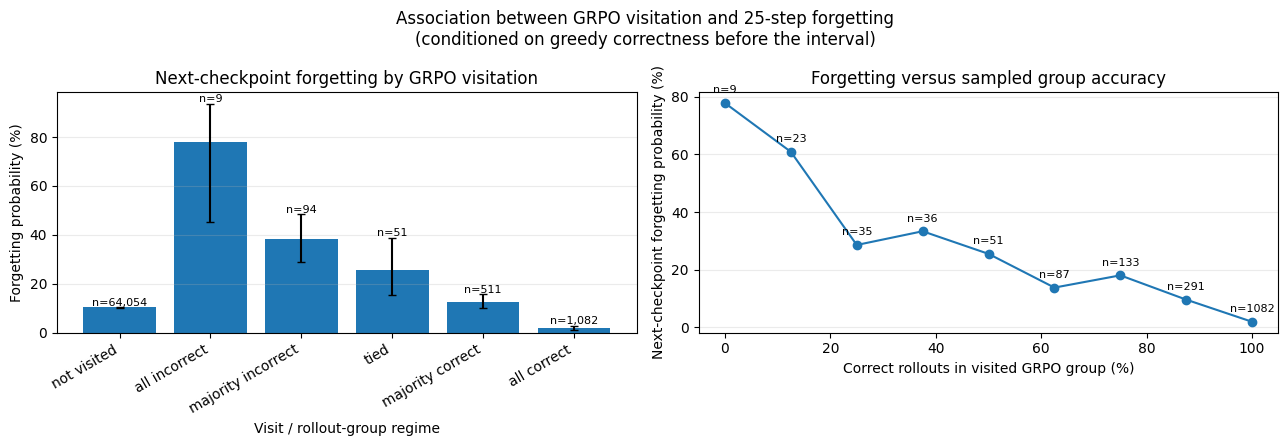

Interpretation: visitation is randomized by the sampler, but rollout-group composition is a post-sampling measure of policy confidence. Treat category differences as associations, not necessarily causal effects.


In [3]:
# How does GRPO visitation relate to forgetting over the next 25 steps?
#
# The rollout logger's `idx` is only a position inside the local generation batch.
# Recover dataset indices from RepeatSampler's seeded torch.randperm, accepting the
# join only if it reproduces every logged gold answer.

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

G = 8
SEED_CANDIDATES = range(256)  # includes script/grpo.py's default seed=42
rollout_frames = []
for rank, path in enumerate(sorted(run_dir.glob("rollouts.rank*.jsonl"))):
    frame = pd.read_json(path, lines=True)
    frame["rank"] = rank
    frame["group"] = frame["idx"] // G
    rollout_frames.append(frame)
rollouts = pd.concat(rollout_frames, ignore_index=True)

# One row per GRPO prompt group.
groups = (
    rollouts.groupby(["global_step", "rank", "group"], sort=True)
    .agg(
        gold=("gold_answer", lambda x: str(x.iloc[0])),
        distinct_golds=("gold_answer", lambda x: x.astype(str).nunique()),
        group_size=("correct", "size"),
        sampled_accuracy=("correct", "mean"),
    )
    .reset_index()
)
assert (groups["group_size"] == G).all(), "Incomplete rollout group"
assert (groups["distinct_golds"] == 1).all(), "A rollout group contains multiple queries"

# Accelerator may concatenate rank-local groups in either blocks or interleaved
# order. Test both orders (and both rank directions) against the logged golds.
def ordered_groups(layout, reverse_ranks=False):
    rank_order = -groups["rank"] if reverse_ranks else groups["rank"]
    work = groups.assign(_rank_order=rank_order)
    keys = ["global_step", "_rank_order", "group"] if layout == "rank_blocks" \
        else ["global_step", "group", "_rank_order"]
    return work.sort_values(keys).drop(columns="_rank_order").reset_index(drop=True)

layouts = {
    f"{layout}{'_reverse' if reverse else ''}": ordered_groups(layout, reverse)
    for layout in ("rank_blocks", "interleaved")
    for reverse in (False, True)
}
gold_by_idx = (
    evals[evals["step"] == steps[0]]
    .sort_values("idx")
    ["gold"].astype(str).tolist()
)

best = None
for seed in SEED_CANDIDATES:
    generator = torch.Generator().manual_seed(seed)
    permutation = torch.randperm(len(gold_by_idx), generator=generator).tolist()
    for layout_name, ordered in layouts.items():
        expected = [gold_by_idx[i] for i in permutation[: len(ordered)]]
        matches = sum(a == b for a, b in zip(expected, ordered["gold"]))
        score = matches / len(ordered)
        if best is None or score > best[0]:
            best = (score, seed, layout_name, permutation)

match_rate, sampler_seed, layout_name, permutation = best
print(f"Sampler reconstruction: seed={sampler_seed}, layout={layout_name}, "
      f"gold validation={match_rate:.2%}")
if match_rate < 0.999:
    raise RuntimeError(
        "Could not reliably recover dataset indices from rollout order. "
        "Add dataset_idx to RolloutLogger before interpreting visitation. "
        f"Best gold match was only {match_rate:.2%}."
    )

visits = layouts[layout_name].copy()
visits["dataset_idx"] = permutation[: len(visits)]
visits["window_start"] = (visits["global_step"] // 25) * 25
visits["window_end"] = visits["window_start"] + 25
visits = visits[visits["window_end"].isin(steps)].copy()

# For each adjacent checkpoint pair, condition on being correct at the start.
# If a query is visited more than once, use its last (closest) rollout group.
def group_regime(p):
    if p == 0:
        return "visited: all incorrect"
    if p < 0.5:
        return "visited: majority incorrect"
    if p == 0.5:
        return "visited: tied"
    if p < 1:
        return "visited: majority correct"
    return "visited: all correct"

outcomes = []
for start, end in zip(steps[:-1], steps[1:]):
    window_visits = (
        visits[visits["window_start"] == start]
        .sort_values("global_step")
        .groupby("dataset_idx", as_index=False)
        .agg(
            visits=("global_step", "size"),
            last_visit_step=("global_step", "last"),
            sampled_accuracy=("sampled_accuracy", "last"),
        )
        .set_index("dataset_idx")
    )
    for idx in correct.index[correct[start]]:
        if idx in window_visits.index:
            visit = window_visits.loc[idx]
            regime = group_regime(float(visit["sampled_accuracy"]))
            sampled_accuracy = float(visit["sampled_accuracy"])
            n_visits = int(visit["visits"])
        else:
            regime = "not visited"
            sampled_accuracy = np.nan
            n_visits = 0
        outcomes.append({
            "idx": idx,
            "start_step": start,
            "end_step": end,
            "regime": regime,
            "sampled_accuracy": sampled_accuracy,
            "n_visits": n_visits,
            "forgotten": not bool(correct.loc[idx, end]),
        })
outcomes = pd.DataFrame(outcomes)

regime_order = [
    "not visited",
    "visited: all incorrect",
    "visited: majority incorrect",
    "visited: tied",
    "visited: majority correct",
    "visited: all correct",
]
summary = (
    outcomes.groupby("regime", observed=True)
    .agg(n=("forgotten", "size"), forgotten=("forgotten", "sum"))
    .reindex(regime_order)
    .dropna()
)
summary["n"] = summary["n"].astype(int)
summary["forgotten"] = summary["forgotten"].astype(int)
summary["forgetting_rate"] = summary["forgotten"] / summary["n"]

# Wilson 95% intervals are stable even for small visited categories.
z = 1.96
p = summary["forgetting_rate"]
n = summary["n"]
denominator = 1 + z**2 / n
center = (p + z**2 / (2 * n)) / denominator
half_width = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denominator
summary["ci_low"] = center - half_width
summary["ci_high"] = center + half_width
baseline = summary.loc["not visited", "forgetting_rate"]
summary["risk_ratio_vs_unvisited"] = summary["forgetting_rate"] / baseline

binary = (
    outcomes.assign(visited=outcomes["n_visits"] > 0)
    .groupby("visited")
    .agg(n=("forgotten", "size"), forgotten=("forgotten", "sum"))
)
binary["forgetting_rate"] = binary["forgotten"] / binary["n"]
binary.index = binary.index.map({False: "not visited", True: "visited"})

accuracy_effect = (
    outcomes.dropna(subset=["sampled_accuracy"])
    .groupby("sampled_accuracy")
    .agg(n=("forgotten", "size"), forgotten=("forgotten", "sum"))
)
accuracy_effect["forgetting_rate"] = accuracy_effect["forgotten"] / accuracy_effect["n"]

summary.to_csv(run_dir / "forgetting_by_visitation_regime.csv")
outcomes.to_csv(run_dir / "forgetting_visitation_events.csv", index=False)

print(f"Mapped {len(visits):,} GRPO query visits; "
      f"{int((outcomes.n_visits > 0).sum()):,} occurred while the query was "
      "greedily correct at the preceding checkpoint.")
print("\nVisited versus unvisited")
display(binary.style.format({"forgetting_rate": "{:.2%}"}))
print("\nForgetting by rollout-group composition")
display(summary.style.format({
    "forgetting_rate": "{:.2%}",
    "ci_low": "{:.2%}",
    "ci_high": "{:.2%}",
    "risk_ratio_vs_unvisited": "{:.2f}×",
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_summary = summary.reset_index()
x = np.arange(len(plot_summary))
y = plot_summary["forgetting_rate"].to_numpy() * 100
yerr = np.vstack([
    (plot_summary["forgetting_rate"] - plot_summary["ci_low"]).to_numpy() * 100,
    (plot_summary["ci_high"] - plot_summary["forgetting_rate"]).to_numpy() * 100,
])
axes[0].bar(x, y, yerr=yerr, capsize=3)
axes[0].set_xticks(x, [s.replace("visited: ", "") for s in plot_summary["regime"]], rotation=30, ha="right")
axes[0].set(title="Next-checkpoint forgetting by GRPO visitation", xlabel="Visit / rollout-group regime", ylabel="Forgetting probability (%)")
for i, (rate, count) in enumerate(zip(y, plot_summary["n"])):
    axes[0].text(i, rate + yerr[1, i] + 0.5, f"n={count:,}", ha="center", fontsize=8)

x2 = accuracy_effect.index.to_numpy() * 100
y2 = accuracy_effect["forgetting_rate"].to_numpy() * 100
axes[1].plot(x2, y2, "o-")
axes[1].set(title="Forgetting versus sampled group accuracy", xlabel="Correct rollouts in visited GRPO group (%)", ylabel="Next-checkpoint forgetting probability (%)")
for x_value, y_value, count in zip(x2, y2, accuracy_effect["n"]):
    axes[1].annotate(f"n={count}", (x_value, y_value), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8)
for ax in axes:
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Association between GRPO visitation and 25-step forgetting\n(conditioned on greedy correctness before the interval)")
fig.tight_layout()
visitation_figure = run_dir / "forgetting_vs_visitation.png"
fig.savefig(visitation_figure, dpi=180, bbox_inches="tight")
plt.show()

print("Interpretation: visitation is randomized by the sampler, but rollout-group "
      "composition is a post-sampling measure of policy confidence. Treat category "
      "differences as associations, not necessarily causal effects.")

In [1]:
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/parse.py").exists())
sys.path.insert(0, str(root))

from src.parse import split_backtracking

In [2]:
# Redundant-backtracking analysis: existence and gradient exposure.
import json
from pathlib import Path

import numpy as np
import pandas as pd

from src.parse import split_backtracking

run_dir = Path.cwd()
if not list(run_dir.glob("rollouts.rank*.jsonl")):
    run_dir = Path("output/forget_gap")

rows = []
totals = {False: 0, True: 0}
for path in sorted(run_dir.glob("rollouts.rank*.jsonl")):
    with path.open() as f:
        for line in f:
            row = json.loads(line)
            totals[row["correct"]] += 1
            parsed = split_backtracking(row["completion"], row["gold_answer"])
            if parsed is None:
                continue
            prefix, suffix = parsed
            text_length = max(len(row["completion"]), 1)
            rows.append({
                **row,
                "prefix": prefix,
                "suffix": suffix,
                "prefix_fraction": len(prefix) / text_length,
                "suffix_fraction": len(suffix) / text_length,
            })

backtracking = pd.DataFrame(rows)
matched = {correct: int((backtracking["correct"] == correct).sum()) for correct in (False, True)}

print("REDUNDANT BACKTRACKING")
print(
    f"Wrong ending:   {matched[False]:,}/{totals[False]:,} "
    f"({matched[False] / totals[False]:.2%}) solved first, backtracked, then ended wrong"
)
print(
    f"Correct ending: {matched[True]:,}/{totals[True]:,} "
    f"({matched[True] / totals[True]:.2%}) solved first, backtracked, then ended correct"
)
print("\nGRADIENT EXPOSURE AMONG MATCHES")
print(
    f"Positive rollouts: median {backtracking.loc[backtracking.correct, 'suffix_fraction'].median():.1%} "
    "of text follows an already-correct prefix and is still positively reinforced."
)
print(
    f"Negative rollouts: median {backtracking.loc[~backtracking.correct, 'prefix_fraction'].median():.1%} "
    "of text precedes the bad turn and is still negatively reinforced."
)
print("These exposure statistics identify the credit-assignment mismatch; they do not by themselves prove causal harm.")


REDUNDANT BACKTRACKING
Wrong ending:   390/5,233 (7.45%) solved first, backtracked, then ended wrong
Correct ending: 4,272/13,967 (30.59%) solved first, backtracked, then ended correct

GRADIENT EXPOSURE AMONG MATCHES
Positive rollouts: median 41.1% of text follows an already-correct prefix and is still positively reinforced.
Negative rollouts: median 48.5% of text precedes the bad turn and is still negatively reinforced.
These exposure statistics identify the credit-assignment mismatch; they do not by themselves prove causal harm.


In [3]:
# Case studies: 10 correct endings and 10 wrong endings.
from html import escape
from IPython.display import HTML, display


def show_cases(correct: bool, n: int = 10) -> None:
    cases = backtracking[backtracking["correct"] == correct].sort_values("global_step")
    cases = cases.iloc[np.linspace(0, len(cases) - 1, min(n, len(cases))).round().astype(int)]
    outcome = "REDUNDANT: ENDED CORRECT" if correct else "HARMFUL: ENDED WRONG"
    suffix_color = "rgba(249,115,22,.14)" if correct else "rgba(239,68,68,.14)"
    cards = []
    for number, (_, row) in enumerate(cases.iterrows(), 1):
        cards.append(f"""
        <section style="margin:14px 0;border:1px solid rgba(127,127,127,.35);border-radius:10px;overflow:hidden">
          <header style="padding:10px 13px;background:rgba(127,127,127,.13)">
            <b>{number:02d} · {outcome}</b> &nbsp; step {row['global_step']} &nbsp;
            gold <b>{escape(str(row['gold_answer']))}</b> &nbsp;
            final <b>{escape(str(row['predicted_answer']))}</b>
          </header>
          <details open style="padding:11px 13px;background:rgba(34,197,94,.11)">
            <summary style="cursor:pointer;font-weight:700">CORRECT REASONING PREFIX ({row['prefix_fraction']:.1%} of text)</summary>
            <pre style="max-height:360px;overflow:auto;white-space:pre-wrap;color:inherit">{escape(row['prefix'])}</pre>
          </details>
          <details open style="padding:11px 13px;background:{suffix_color}">
            <summary style="cursor:pointer;font-weight:700">BACKTRACKING SUFFIX ({row['suffix_fraction']:.1%} of text)</summary>
            <pre style="max-height:360px;overflow:auto;white-space:pre-wrap;color:inherit">{escape(row['suffix'])}</pre>
          </details>
        </section>
        """)
    title = "Correct rollouts: unnecessary backtracking" if correct else "Incorrect rollouts: correct prefix lost to backtracking"
    display(HTML(f"<h2>{title}</h2>" + "".join(cards)))


show_cases(correct=True)
show_cases(correct=False)